In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [4]:
# Import Microsoft's Stock Data
ms = pd.read_csv("data/microsoft.csv")

In [5]:
# Show the the first 5 rows of Microsoft's Data Frame
ms.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
1,2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2,2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
3,2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
4,2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


In [6]:
# Print values for Row 1 and Column 2 of the Microsoft stock data
print(ms.iloc[0,1])

46.73


In [7]:
# Show size of DataFrame
ms.shape

(780, 7)

In [9]:
# Add the index column  to Imported DataFrame
ms = pd.read_csv("data/Microsoft.csv", index_col="Date")

In [10]:
# First 5 rows of Microsoft's DataFrame
ms.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


In [11]:
# Show Summary Statistics of DataFrame
ms.describe()

,Open,High,Low,Close,Adj Close,Volume
count,780.000000,780.000000,780.000000,780.000000,780.000000,7.800000e+02
mean,58.912308,59.372308,58.465000,58.945397,56.931553,2.978900e+07
std,12.852040,12.868060,12.802831,12.830350,13.670080,1.522319e+07
min,40.340000,40.740002,39.720001,40.290001,37.267815,7.425600e+06
25%,47.894998,48.295000,47.535001,47.974998,44.792073,2.096685e+07
50%,56.150002,56.640001,55.700001,56.209999,53.775458,2.623125e+07
75%,67.892500,68.174997,67.447500,67.740000,66.565508,3.408020e+07
max,95.139999,96.070000,93.720001,95.010002,94.565781,1.691640e+08


In [12]:
# Select Price Information for Microsoft in 2016
ms_2016 = ms.loc['2016-01-01':'2016-12-31']

In [13]:
# print the price of Microsoft on '2016-03-16'
ms_2016.loc['2016-03-16']

Open         5.345000e+01
High         5.460000e+01
Low          5.340000e+01
Close        5.435000e+01
Adj Close    5.187095e+01
Volume       3.169170e+07
Name: 2016-03-16, dtype: float64

In [ ]:
#Locate a particular row of data using "Selection by position"

In [14]:
# print the opening price of the first row
print(ms.iloc[0, 0])

46.73


In [15]:
# print the opening price of the last row
print(ms.iloc[-1, 0])

90.559998


In [ ]:
# Plot the stock data using plot() method

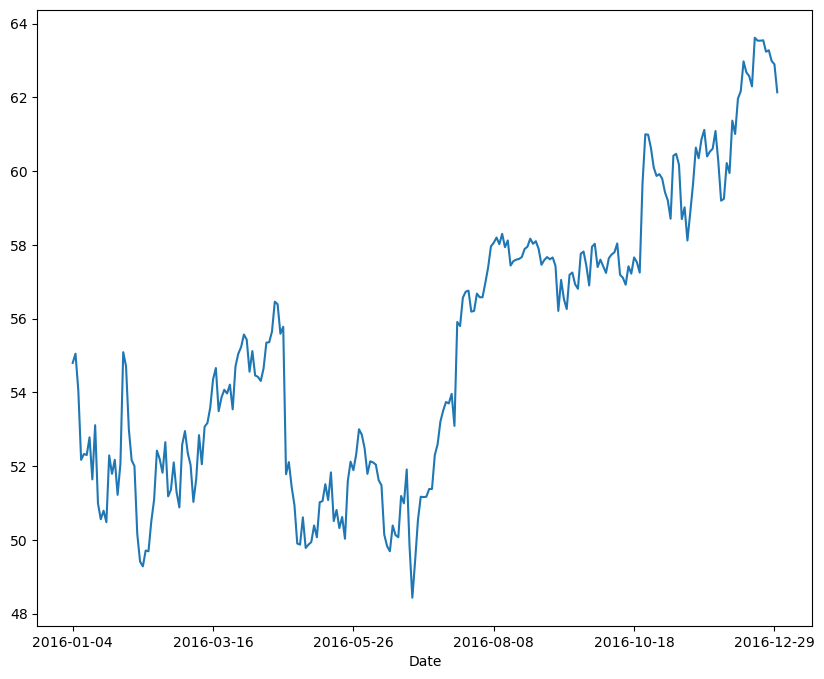

In [16]:
# Plot the Closing price of Microsoft in 2016
plt.figure(figsize =(10,8))
ms_2016['Close'].plot()
plt.show()

In [ ]:
# Create a new column in the DataFrame (1) - Price difference
# Price Difference = Tomorrow's Closing Price - Today's Closing Price

In [17]:
# Create a new column(Price Difference) in the Microsoft DataFrame
ms["PriceDiff"] = ms["Close"].shift(-1) -ms["Close"]

In [18]:
# Confirm the new column has been created
ms.head()

,Open,High,Low,Close,Adj Close,Volume,PriceDiff
Date,,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500,0.309997
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900,-0.429996
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900,-0.680000
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900,0.579998
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100,1.360000


In [19]:
print(ms["PriceDiff"].loc["2015-01-05"])

-0.6799999999999997


In [ ]:
# Create a new column in the DataFrame (2) - Daily return
# Daily Return = PriceDiff / Close

In [20]:
# Create a new column(Return column) in the MS DataFrame
ms["Return"] = ms["PriceDiff"] / ms["Close"]

In [21]:
print(ms["Return"].loc["2015-01-05"])

-0.014677314281143345


In [22]:
ms.head()

,Open,High,Low,Close,Adj Close,Volume,PriceDiff,Return
Date,,,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500,0.309997,0.006674
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900,-0.429996,-0.009196
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900,-0.680000,-0.014677
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900,0.579998,0.012705
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100,1.360000,0.029418


In [ ]:
# Create  a new column Direction. 
# The List Comprehension means : if the price difference is larger than 0, denote as 1
# Otherwise, denote as 0, for every record in the DataFrame - fb


In [23]:
# Create a new column(Direction) using List Comprehension
ms["Direction"] = np.where(ms["PriceDiff"]> 0,1,0)

In [24]:
# Run the following code to show the price difference on 2015-01-05
print('Price difference on {} is {}. direction is {}'.format('2015-01-05', ms['PriceDiff'].loc['2015-01-05'], ms['Direction'].loc['2015-01-05']))

Price difference on 2015-01-05 is -0.6799999999999997. direction is 0


In [25]:
ms.head()

,Open,High,Low,Close,Adj Close,Volume,PriceDiff,Return,Direction
Date,,,,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500,0.309997,0.006674,1
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900,-0.429996,-0.009196,0
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900,-0.680000,-0.014677,0
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900,0.579998,0.012705,1
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100,1.360000,0.029418,1


In [ ]:
# Create a new column in the DataFrame using Rolling Window calculation (.rolling()) - Moving average

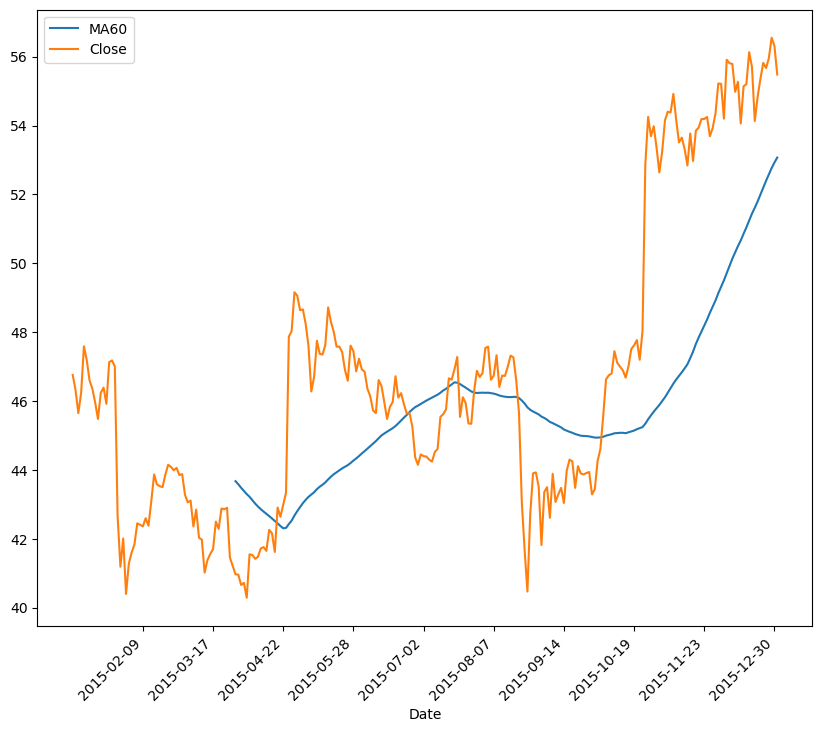

In [26]:
# You can use .rolling() to calculate any numbers of days' Moving Average. This is your turn to calculate "60 days"
# moving average of Microsoft, rename it as "ma60". And follow the codes above in plotting a graph

ms['ma60'] = ms['Close'].rolling(60).mean()

#plot the moving average
plt.figure(figsize=(10, 8))
ms['ma60'].loc['2015-01-01':'2015-12-31'].plot(label='MA60')
ms['Close'].loc['2015-01-01':'2015-12-31'].plot(label='Close')
plt.legend()
plt.xticks(rotation=45, ha='right');

In [ ]:
# Build a simple trading strategy
# Munging the stock data for Microsoft and add two columns - MA10 and MA50

In [28]:
ms = pd.read_csv("data/Microsoft.csv", index_col="Date")
ms['MA10'] = ms['Close'].rolling(10).mean()
ms['MA50'] = ms['Close'].rolling(50).mean()
ms = ms.dropna()
ms.head()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50
Date,,,,,,,,
2015-03-13,40.700001,41.470001,40.610001,41.380001,38.443489,58007700,42.495,44.0034
2015-03-16,41.470001,41.639999,41.279999,41.560001,38.610714,35273500,42.263,43.9056
2015-03-17,41.369999,41.830002,41.150002,41.700001,38.740784,31587200,42.105,43.8044
2015-03-18,41.430000,42.830002,41.330002,42.500000,39.484009,43971800,42.049,43.7278
2015-03-19,42.259998,42.590000,42.220001,42.290001,39.288918,33879100,41.967,43.6606


In [ ]:
# Add "Shares" column to make decisions base on the strategy

In [29]:
# Add a new column "Shares", if MA10>MA50, denote as 1 (long one share of stock), otherwise, denote as 0 (do nothing)

ms["Shares"] = np.where(ms["MA10"] > ms["MA50"], 1, 0)
print(ms["Shares"])

Date
2015-03-13    0
2015-03-16    0
2015-03-17    0
2015-03-18    0
2015-03-19    0
             ..
2018-01-30    1
2018-01-31    1
2018-02-01    1
2018-02-02    1
2018-02-05    1
Name: Shares, Length: 731, dtype: int64


In [ ]:
# Add a new column "Profit" using List Comprehension, for any rows in ms, if Shares=1, 
# the profit is calculated as the close price of tomorrow - the close price of today. Otherwise the profit is 0.

In [30]:
# Create a new column called Close1(Tomorrow's closing price)
ms["Close1"] = ms["Close"].shift(-1)


In [31]:
# Create a new column called Profit where if Shares = 1 there is profit and if Shares = 0 there is no profit
ms["Profit"] = np.where(ms["Shares"]== 1, ms["Close1"]- ms["Close"], 0 )

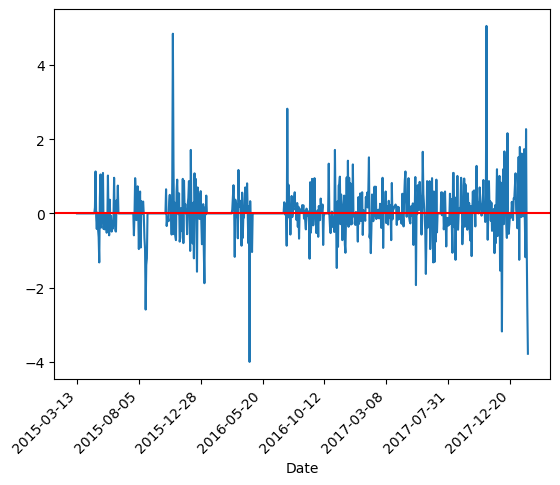

In [32]:
# Plot a graph to show the profit/loss
ms["Profit"].plot()
plt.axhline(y=0, color='red')
plt.xticks(rotation=45, ha='right');

In [ ]:
#  Use Cumulative Sum to display our model's performance if we follow the strategy

In [33]:
ms["Wealth"] = ms["Profit"].cumsum()
ms.tail()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,Shares,Close1,Profit,Wealth
Date,,,,,,,,,,,,
2018-01-30,93.300003,93.660004,92.099998,92.739998,92.306389,38635100,91.862,86.5244,1,95.010002,2.270004,30.540009
2018-01-31,93.750000,95.400002,93.510002,95.010002,94.565781,48756300,92.349,86.7606,1,94.260002,-0.750000,29.790009
2018-02-01,94.790001,96.070000,93.580002,94.260002,93.819290,47227900,92.765,86.9978,1,91.779999,-2.480003,27.310006
2018-02-02,93.639999,93.970001,91.500000,91.779999,91.350883,47867800,92.943,87.1828,1,88.000000,-3.779999,23.530007
2018-02-05,90.559998,93.239998,88.000000,88.000000,87.588554,51031500,92.582,87.2684,1,NaN,NaN,NaN


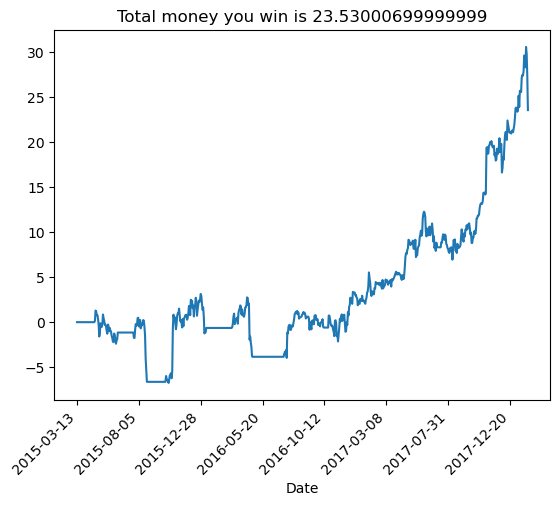

In [34]:
# Create a plot for Total Profit made
ms["Wealth"].plot()
plt.title("Total money you win is {}".format(ms.loc[ms.index[-2], "Wealth"]))
plt.xticks(rotation=45, ha="right");